In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import PCA_law_np

In [2]:
# --- Load dataset ---
digits = load_digits()
X, Y = digits.data, digits.target
# --- Split into train and test sets ---
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y
)

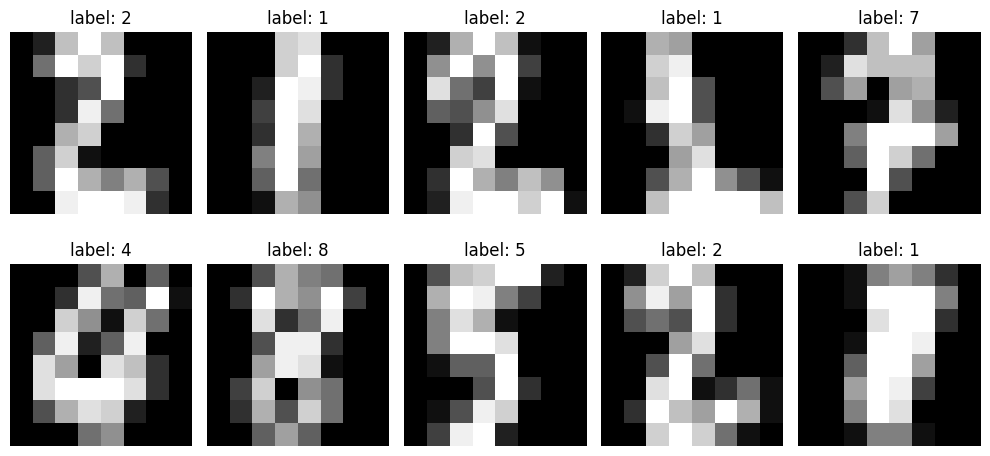

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"label: {Y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
importlib.reload(PCA_law_np)

<module 'PCA_law_np' from '/home/anti/Documents/ML in Practice I/PCA_law_np.py'>

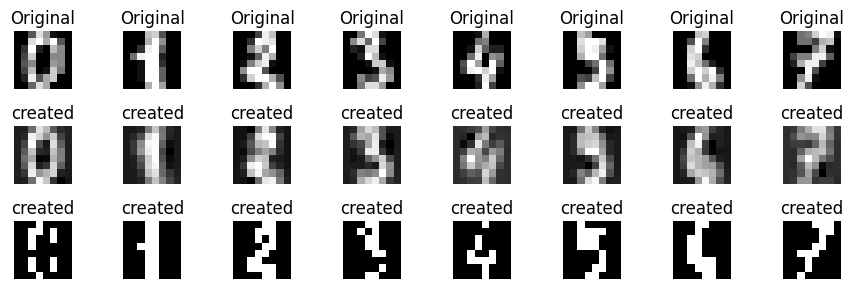

In [5]:
from PCA_law_np import PCA_law, PCA_classifier

n_components=13
pp = PCA_law(n_components= n_components)
pp.fit(X)
ycomp = pp.compress(X)
Xrec = pp.reconstruct(ycomp)
# Compare original and reconstructed digits
fig, axes = plt.subplots(nrows=3, ncols=8, figsize=(9, 3))
for i in range(8):
    axes[0, i].imshow(X[i].reshape(8,8), cmap='gray')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(Xrec[i].reshape(8,8), cmap='gray')
    axes[1, i].set_title("created")
    Xmod = np.array([ 1 if xi > 10 else 0 for xi in X[i]])
    axes[2, i].imshow(Xmod.reshape(8,8), cmap='gray')
    axes[2, i].set_title("created")
    for ax in axes[:, i]: ax.axis('off')
plt.tight_layout()
plt.show()

In [105]:
Yrange= set(Y)
Xdict = { int(y):X[Y==y] for y in Yrange}

In [124]:
Xdict = { int(y):X[Y==y] for y in Yrange}
npoints = 24
laws = { int(y):[] for y in Yrange}
for x,y in zip(X,Y):
    indices = np.sort(np.argsort(x)[::-1][:npoints])
    laws[int(y)].append(indices)

In [125]:
Xdict = { int(y):X[Y==y] for y in Yrange}
laws = { int(y):[] for y in Yrange}
for x,y in zip(X,Y):
    indices = np.array([ i for i,xi in enumerate(x) if xi > 10])
    laws[int(y)].append(indices)

(array([ 4.,  9., 14., 41., 33., 40., 20., 11.,  7.,  3.]),
 array([ 31. ,  43.6,  56.2,  68.8,  81.4,  94. , 106.6, 119.2, 131.8,
        144.4, 157. ]),
 <BarContainer object of 10 artists>)

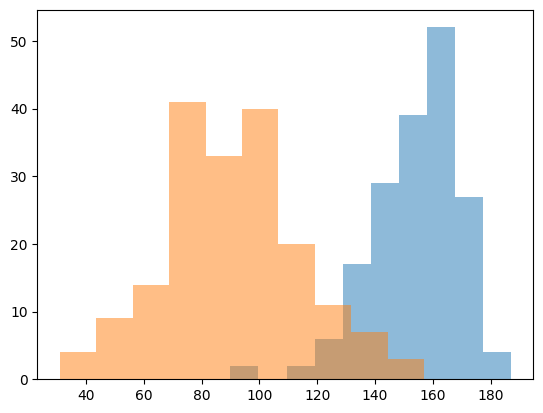

In [126]:
plt.hist(np.sum(Xdict[0][:,laws[0][0]], axis=1), alpha=0.5)
plt.hist(np.sum(Xdict[1][:,laws[0][0]], axis=1), alpha=0.5)

(array([ 3.,  5.,  7.,  4., 14., 25., 20., 36., 46., 22.]),
 array([ 79. ,  97.9, 116.8, 135.7, 154.6, 173.5, 192.4, 211.3, 230.2,
        249.1, 268. ]),
 <BarContainer object of 10 artists>)

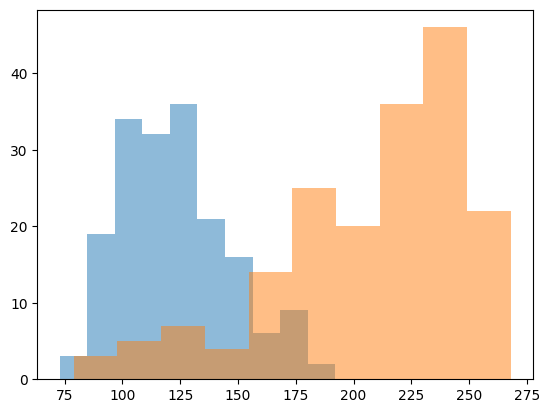

In [ ]:
plt.hist(np.sum(Xdict[0][:,laws[1][0]], axis=1), alpha=0.5)
plt.hist(np.sum(Xdict[1][:,laws[1][0]], axis=1), alpha=0.5)

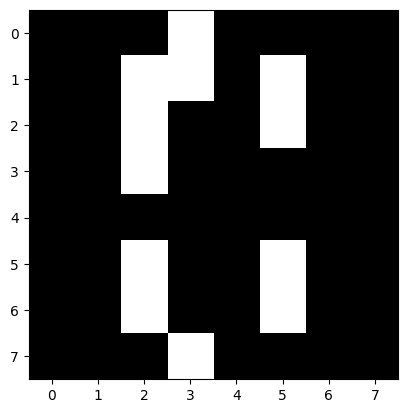

In [141]:
selected_laws = [laws[l][:3] for l in laws]
pic = np.zeros(64)
pic[selected_laws[0][0]] = 1
plt.imshow(pic.reshape(8,8), cmap='gray')

In [142]:
np.sum(X[:,laws[1][0]], axis=1)

array([100., 253., 188., ..., 229., 162., 186.], shape=(1797,))

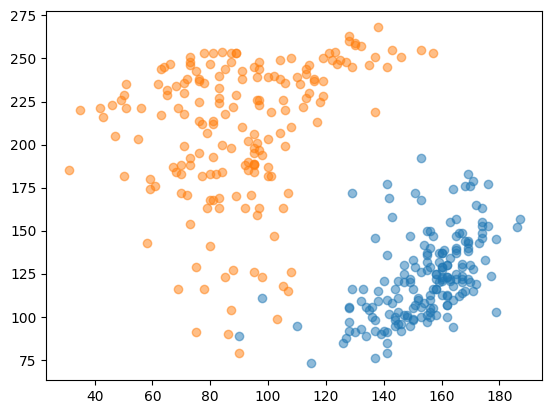

In [88]:
RR = []
for i in range(2):
    R0 = np.sum(Xdict[i][:,laws[0][0]], axis=1)
    R1 = np.sum(Xdict[i][:,laws[1][0]], axis=1)
    RR.append([R0,R1])
for R in RR:
    plt.scatter(R[0], R[1], alpha=0.5)
#R0 = np.array([np.sum(Xdict[0][:,laws[0][0]], axis=1), np.sum(Xdict[0][:,laws[1][0]], axis=1)]).T
#R1 = np.array([np.sum(Xdict[1][:,laws[0][0]], axis=1), np.sum(Xdict[1][:,laws[1][0]], axis=1)]).T
#plt.scatter(R0[:,0], R0[:,1], alpha=0.5)
#plt.scatter(R1[:,0], R1[:,1], alpha=0.5)

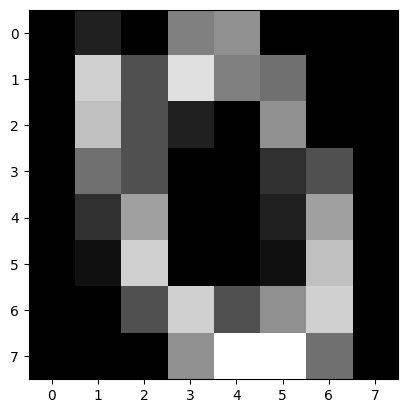

In [67]:
imin = np.argmin(np.sum(Xdict[0][:,laws[0][0]], axis=1))
plt.imshow(Xdict[0][imin].reshape(8,8), cmap='gray')

(array([ 1.,  5., 24., 47., 36., 28., 15., 13., 10.,  3.]),
 array([1443., 1740., 2037., 2334., 2631., 2928., 3225., 3522., 3819.,
        4116., 4413.]),
 <BarContainer object of 10 artists>)

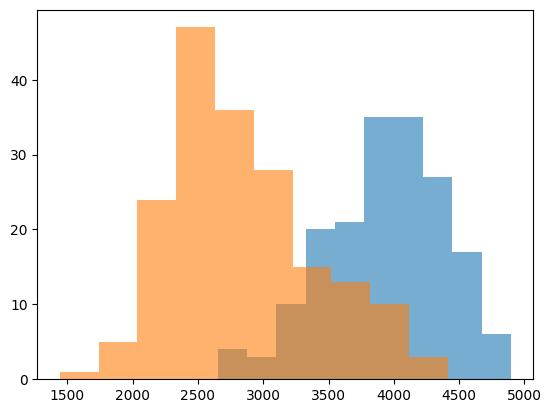

In [81]:
plt.hist(np.sum([np.sum(Xdict[0][:,l], axis=1) for l in laws[0][:20]], axis=0),alpha=0.6)
plt.hist(np.sum([np.sum(Xdict[1][:,l], axis=1) for l in laws[0][:20]], axis=0),alpha=0.6)

In [62]:
results = []
for img, label in zip(X,Y):
    results.append((np.argmax([np.mean([ np.sum(img[l]) for l in L]) for L in laws.values()]), label))
results=np.array(results)

In [63]:
accuracy_score(results[:,1], results[:,0])

0.8720089037284363

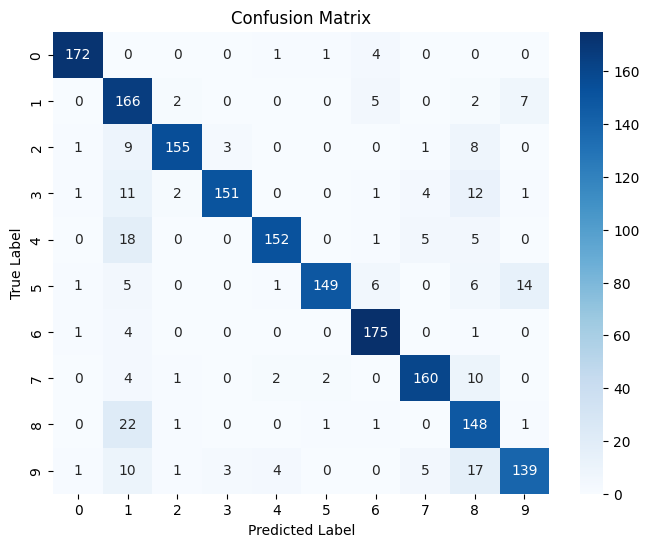

In [64]:
results=np.array(results)
conf_mat = confusion_matrix(results[:,1], results[:,0])
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=Yrange, yticklabels=Yrange)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()